Este notebook analiza la estructura interna de las anomalías detectadas por el sistema híbrido contextual. En lugar de volver a entrenar detectores, se estudia si los segmentos anómalos forman perfiles coherentes de comportamiento marítimo y si las anomalías sintéticas se concentran de manera consistente dentro de dichos perfiles.

Para evitar leakage conceptual, las variables usadas para clusterizar serán exclusivamente variables descriptivas del comportamiento del segmento. Las etiquetas de evaluación (`is_synthetic`, `anomaly_type`) y los scores del detector (`hybrid_score`, `ae_score`, etc.) se usarán únicamente **después** del clustering, para validar e interpretar los resultados.

## Imports

In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import json
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score,
    adjusted_rand_score,
    normalized_mutual_info_score,
    homogeneity_score,
    completeness_score
)

from scipy.stats import chi2_contingency

# Intentar importar HDBSCAN
try:
    import hdbscan
    HDBSCAN_AVAILABLE = True
except ImportError:
    HDBSCAN_AVAILABLE = False

sns.set(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)

## Carga de datos

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
base_path = "/content/drive/MyDrive/TFG/"
hybrid_path = os.path.join(base_path, "results/hybrid_scoring/")

input_file = os.path.join(hybrid_path, "holdout_with_all_scores.csv")

print("Archivo esperado:", input_file)
print("Existe:", os.path.exists(input_file))

Archivo esperado: /content/drive/MyDrive/TFG/results/hybrid_scoring/holdout_with_all_scores.csv
Existe: True


In [7]:
df = pd.read_csv(input_file)

print("Shape:", df.shape)
print("\nPrimeras columnas:")
print(df.columns.tolist()[:50])

df.head()

Shape: (156389, 66)

Primeras columnas:
['segment_id', 'MMSI', 'trajectory_id', 'speed_mean', 'speed_std', 'speed_max', 'delta_course_mean', 'delta_course_max', 'turning_rate_mean', 'turning_rate_max', 'acceleration_mean', 'acceleration_max', 'delta_t_mean', 'delta_t_max', 'distance_km', 'duration', 'ship_type', 'lat_mean', 'lon_mean', 'lat_start', 'lon_start', 'lat_end', 'lon_end', 'course_instability', 'speed_cv', 'turning_intensity', 'speed_variation', 'avg_speed_kmh', 'ais_gap', 'acceleration_instability', 'turning_ratio', 'slow_motion', 'high_speed_flag', 'low_distance_flag', 'points_density', 'erratic_motion_flag', 'stop_like_flag', 'is_synthetic', 'anomaly_type', 'ae_score', 'ml_score_norm', 'ae_pred_tuned', 'lof_pred', 'lof_score_raw', 'lof_score', 'speed_mean_p90', 'speed_mean_p95', 'speed_max_p95', 'turning_rate_mean_p90', 'turning_rate_mean_p95']


,segment_id,MMSI,trajectory_id,speed_mean,speed_std,speed_max,delta_course_mean,delta_course_max,turning_rate_mean,turning_rate_max,acceleration_mean,acceleration_max,delta_t_mean,delta_t_max,distance_km,duration,ship_type,lat_mean,lon_mean,lat_start,lon_start,lat_end,lon_end,course_instability,speed_cv,turning_intensity,speed_variation,avg_speed_kmh,ais_gap,acceleration_instability,turning_ratio,slow_motion,high_speed_flag,low_distance_flag,points_density,erratic_motion_flag,stop_like_flag,is_synthetic,anomaly_type,ae_score,ml_score_norm,ae_pred_tuned,lof_pred,lof_score_raw,lof_score,speed_mean_p90,speed_mean_p95,speed_max_p95,turning_rate_mean_p90,turning_rate_mean_p95,turning_rate_max_p95,course_instability_p90,course_instability_p95,ais_gap_p90,ais_gap_p95,rule_speed_anomaly,rule_turning_anomaly,rule_erratic_course,rule_ais_gap,rule_dangerous_combo,rule_stop_gap_combo,rule_score_raw,rule_score_norm,hybrid_score,hybrid_pred,hybrid_context_pred
0,923622,367689040,1,9.985714,0.488229,10.6,9.833333,17.0,0.089193,0.175000,0.001090,0.006329,130.000000,340.0,3.942684,759.0,Service,30.899594,-91.526617,30.91241,-91.54270,30.88682,-91.51631,7.166667,0.048893,0.075641,0.614286,18.700388,2.615385,0.005239,1.962020,0,0,0,0.007692,0,0,0,normal,0.000082,0.000020,0,0,-1.071137,1.071137,5.110000,7.276923,8.5,0.846005,1.114039,2.525357,93.943056,111.518269,2.345277,3.072328,1,0,0,1,0,0,2.5,0.304878,0.060992,0,0
1,33563,255806265,0,12.807143,0.133440,13.0,3.230769,12.5,0.047046,0.176056,-0.000448,0.001449,67.857143,71.0,5.805101,881.0,Tanker,40.761712,-74.008760,40.78404,-73.99240,40.73704,-74.01887,9.269231,0.010419,0.047611,0.192857,23.721089,1.046316,0.001897,3.742167,0,0,0,0.014737,0,0,0,normal,0.000032,0.000006,0,0,-1.090730,1.090730,12.561538,13.771000,14.0,0.341979,0.488180,0.973333,74.800000,96.525000,2.139544,2.684465,1,0,0,0,0,0,1.0,0.121951,0.024395,0,0
2,1128601,368116110,0,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,71.583333,81.0,0.009641,780.0,Special_Craft,27.760575,-82.635991,27.76058,-82.63599,27.76058,-82.63599,0.000000,0.000000,0.000000,0.000000,0.044498,1.131548,0.000000,0.000000,1,0,1,0.013970,0,1,0,normal,0.000020,0.000003,0,0,-0.994893,0.994893,2.830000,5.692308,6.6,0.521194,0.791777,2.209859,75.350000,97.743175,2.105558,2.560822,0,0,0,0,0,0,0.0,0.000000,0.000002,0,0
3,1057779,368042990,4,0.323077,0.288641,1.1,96.200000,161.6,1.910179,8.080000,-0.002524,0.020000,66.923077,81.0,7.433303,800.0,Service,28.930232,-89.409091,28.93241,-89.40758,28.93244,-89.40756,65.400000,0.893410,1.437471,0.776923,33.449712,1.210345,0.022524,4.229968,1,0,0,0.014943,0,0,0,normal,0.000759,0.000211,0,0,-1.018800,1.018800,5.110000,7.276923,8.5,0.846005,1.114039,2.525357,93.943056,111.518269,2.345277,3.072328,0,1,0,0,0,0,1.0,0.121951,0.024559,0,0
4,1367522,368395970,0,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,216.600000,361.0,0.002867,722.0,Special_Craft,37.908032,-122.382912,37.90803,-122.38291,37.90804,-122.38291,0.000000,0.000000,0.000000,0.000000,0.014293,1.666667,0.000000,0.000000,1,0,1,0.004617,0,1,0,normal,0.000033,0.000007,0,0,-1.015308,1.015308,2.830000,5.692308,6.6,0.521194,0.791777,2.209859,75.350000,97.743175,2.105558,2.560822,0,0,0,0,0,0,0.0,0.000000,0.000005,0,0


In [9]:
print("Columnas disponibles:")
for col in df.columns:
    print(col)

print("\nDistribución de hybrid_context_pred:")
if "hybrid_context_pred" in df.columns:
    print(df["hybrid_context_pred"].value_counts(dropna=False))
else:
    print("No existe 'hybrid_context_pred'.")

print("\nDistribución de is_synthetic:")
if "is_synthetic" in df.columns:
    print(df["is_synthetic"].value_counts(dropna=False))
else:
    print("No existe 'is_synthetic'.")

print("\nDistribución de anomaly_type:")
if "anomaly_type" in df.columns:
    print(df["anomaly_type"].value_counts(dropna=False))
else:
    print("No existe 'anomaly_type'.")

print("\nDistribución de ship_type:")
if "ship_type" in df.columns:
    print(df["ship_type"].value_counts(dropna=False))
else:
    print("No existe 'ship_type'.")

Columnas disponibles:
segment_id
MMSI
trajectory_id
speed_mean
speed_std
speed_max
delta_course_mean
delta_course_max
turning_rate_mean
turning_rate_max
acceleration_mean
acceleration_max
delta_t_mean
delta_t_max
distance_km
duration
ship_type
lat_mean
lon_mean
lat_start
lon_start
lat_end
lon_end
course_instability
speed_cv
turning_intensity
speed_variation
avg_speed_kmh
ais_gap
acceleration_instability
turning_ratio
slow_motion
high_speed_flag
low_distance_flag
points_density
erratic_motion_flag
stop_like_flag
is_synthetic
anomaly_type
ae_score
ml_score_norm
ae_pred_tuned
lof_pred
lof_score_raw
lof_score
speed_mean_p90
speed_mean_p95
speed_max_p95
turning_rate_mean_p90
turning_rate_mean_p95
turning_rate_max_p95
course_instability_p90
course_instability_p95
ais_gap_p90
ais_gap_p95
rule_speed_anomaly
rule_turning_anomaly
rule_erratic_course
rule_ais_gap
rule_dangerous_combo
rule_stop_gap_combo
rule_score_raw
rule_score_norm
hybrid_score
hybrid_pred
hybrid_context_pred

Distribución de h

El clustering no se aplica sobre todo el holdout, porque eso mezclaría tráfico normal y tráfico anómalo y probablemente produciría clusters que separen “normalidad” frente a “anomalía”, en vez de perfilar distintos tipos de anomalía.

Por ello, el análisis principal se realiza sobre el subconjunto de segmentos ya priorizados por el sistema híbrido contextual.

## Subconjuntos

In [10]:
df_all = df.copy()

if "hybrid_context_pred" not in df.columns:
    raise ValueError("No existe la columna 'hybrid_context_pred'. Revisa el notebook 5.")

df_anom = df[df["hybrid_context_pred"] == 1].copy()

print("Holdout completo:", df_all.shape)
print("Anomalías contextuales:", df_anom.shape)

if "hybrid_score" in df.columns:
    score_thr = df["hybrid_score"].quantile(0.95)
    df_top = df[df["hybrid_score"] >= score_thr].copy()
    print("Top 5% hybrid_score:", df_top.shape)
else:
    df_top = None
    print("No existe 'hybrid_score'; no se crea df_top.")

Holdout completo: (156389, 66)
Anomalías contextuales: (7069, 66)
Top 5% hybrid_score: (7820, 66)


Selección de variables

In [11]:
candidate_cluster_features = [
    "speed_mean",
    "speed_max",
    "delta_course_mean",
    "delta_course_max",
    "turning_rate_mean",
    "turning_rate_max",
    "course_instability",
    "distance_km",
    "duration",
    "ais_gap",
    "slow_motion",
    "high_speed_flag",
    "low_distance_flag",
    "erratic_motion_flag"
]

cluster_features = [col for col in candidate_cluster_features if col in df_anom.columns]

print("Variables candidatas encontradas:", len(cluster_features))
print(cluster_features)

if len(cluster_features) < 5:
    raise ValueError("Muy pocas variables de clustering disponibles. Revisa columnas guardadas.")

Variables candidatas encontradas: 14
['speed_mean', 'speed_max', 'delta_course_mean', 'delta_course_max', 'turning_rate_mean', 'turning_rate_max', 'course_instability', 'distance_km', 'duration', 'ais_gap', 'slow_motion', 'high_speed_flag', 'low_distance_flag', 'erratic_motion_flag']


In [12]:
nulls = df_anom[cluster_features].isna().sum().sort_values(ascending=False)
print(nulls[nulls > 0])

df_anom[cluster_features].describe().T

Series([], dtype: int64)


,count,mean,std,min,25%,50%,75%,max
speed_mean,7069.0,1.513791,3.506052,0.0,0.000000,0.016667,0.700000,30.814286
speed_max,7069.0,2.730737,5.568190,0.0,0.000000,0.100000,2.300000,43.400000
delta_course_mean,7069.0,36.784869,35.891322,0.0,0.700000,31.284615,62.510000,263.224278
delta_course_max,7069.0,89.959632,74.490325,0.0,1.700000,107.900000,161.700000,488.557976
turning_rate_mean,7069.0,0.503673,0.987341,0.0,0.008335,0.356752,0.752980,40.567070
turning_rate_max,7069.0,1.883644,7.160075,0.0,0.019178,0.950820,2.208571,175.000000
course_instability,7069.0,53.303657,47.597311,0.0,0.911111,53.300000,91.766667,324.588024
distance_km,7069.0,3.890455,41.951173,0.0,0.008350,0.019456,0.195603,2130.247957
duration,7069.0,801.646642,181.472981,199.0,720.000000,786.000000,841.000000,1606.935548
ais_gap,7069.0,2.890709,2.023577,1.0,1.391753,2.432139,3.319206,25.030517


## Preparación de la matriz

In [13]:
X_raw = df_anom[cluster_features].copy()

numeric_features = X_raw.select_dtypes(include=[np.number]).columns.tolist()
non_numeric_features = [c for c in cluster_features if c not in numeric_features]

print("Numéricas:", numeric_features)
print("No numéricas:", non_numeric_features)

if non_numeric_features:
    print("\nAdvertencia: hay columnas no numéricas. Se intentarán convertir.")
    for col in non_numeric_features:
        X_raw[col] = pd.to_numeric(X_raw[col], errors="coerce")

numeric_features = X_raw.select_dtypes(include=[np.number]).columns.tolist()

imputer = SimpleImputer(strategy="median")
scaler = StandardScaler()

X_imputed = imputer.fit_transform(X_raw[numeric_features])
X_scaled = scaler.fit_transform(X_imputed)

X_scaled_df = pd.DataFrame(X_scaled, columns=numeric_features, index=df_anom.index)

print("Shape final de X:", X_scaled_df.shape)
X_scaled_df.head()

Numéricas: ['speed_mean', 'speed_max', 'delta_course_mean', 'delta_course_max', 'turning_rate_mean', 'turning_rate_max', 'course_instability', 'distance_km', 'duration', 'ais_gap', 'slow_motion', 'high_speed_flag', 'low_distance_flag', 'erratic_motion_flag']
No numéricas: []
Shape final de X: (7069, 14)


,speed_mean,speed_max,delta_course_mean,delta_course_max,turning_rate_mean,turning_rate_max,course_instability,distance_km,duration,ais_gap,slow_motion,high_speed_flag,low_distance_flag,erratic_motion_flag
17,-0.431796,-0.490452,-0.891918,-0.951327,-0.483296,-0.248274,-0.818984,-0.092662,-0.449943,-0.934406,0.500707,2.089857,0.481848,-0.392824
21,-0.422288,-0.472492,1.403715,1.171247,0.678708,0.095602,0.771818,-0.092744,-0.609757,0.301773,0.500707,-0.478502,0.481848,2.545668
37,-0.420386,-0.472492,1.614436,1.139025,0.020099,-0.127456,0.562495,-0.092691,-0.411367,-0.374328,0.500707,-0.478502,0.481848,-0.392824
48,-0.335527,-0.364729,-0.519040,0.313356,-0.317926,-0.104845,0.879087,-0.090470,-0.119291,-0.374302,0.500707,-0.478502,0.481848,-0.392824
63,0.766218,0.569213,0.532621,0.878570,0.396526,0.097166,0.970635,-0.050649,0.216871,-0.216704,-1.997175,-0.478502,-2.075345,2.545668


## Selección de K

La elección del número de clusters no se basará solo en una métrica. Se evaluarán varias particiones usando:

- **Silhouette**: mayor es mejor.
- **Calinski-Harabasz**: mayor es mejor.
- **Davies-Bouldin**: menor es mejor.

Sin embargo, estas métricas tienden a favorecer clusters convexos y compactos, por lo que la decisión final también tendrá en cuenta la estabilidad de tamaños y la interpretabilidad marítima de los perfiles obtenidos.

In [14]:
k_values = list(range(2, 9))
k_results = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = kmeans.fit_predict(X_scaled_df)

    sizes = pd.Series(labels).value_counts().sort_index()

    result = {
        "k": k,
        "silhouette": silhouette_score(X_scaled_df, labels),
        "calinski_harabasz": calinski_harabasz_score(X_scaled_df, labels),
        "davies_bouldin": davies_bouldin_score(X_scaled_df, labels),
        "min_cluster_size": sizes.min(),
        "max_cluster_size": sizes.max(),
        "n_clusters_found": len(np.unique(labels))
    }
    k_results.append(result)

k_results_df = pd.DataFrame(k_results).round(4)
k_results_df

,k,silhouette,calinski_harabasz,davies_bouldin,min_cluster_size,max_cluster_size,n_clusters_found
0,2,0.4071,2299.2507,1.3166,1394,5675,2
1,3,0.3084,2288.5981,1.2563,1323,2875,3
2,4,0.3175,2170.8250,1.0691,20,2875,4
3,5,0.3390,2046.9841,0.9988,20,2774,5
4,6,0.3555,1983.2512,1.0159,20,2717,6
5,7,0.3803,1971.0747,0.9414,20,2609,7
6,8,0.4027,1985.2484,0.9321,20,2216,8


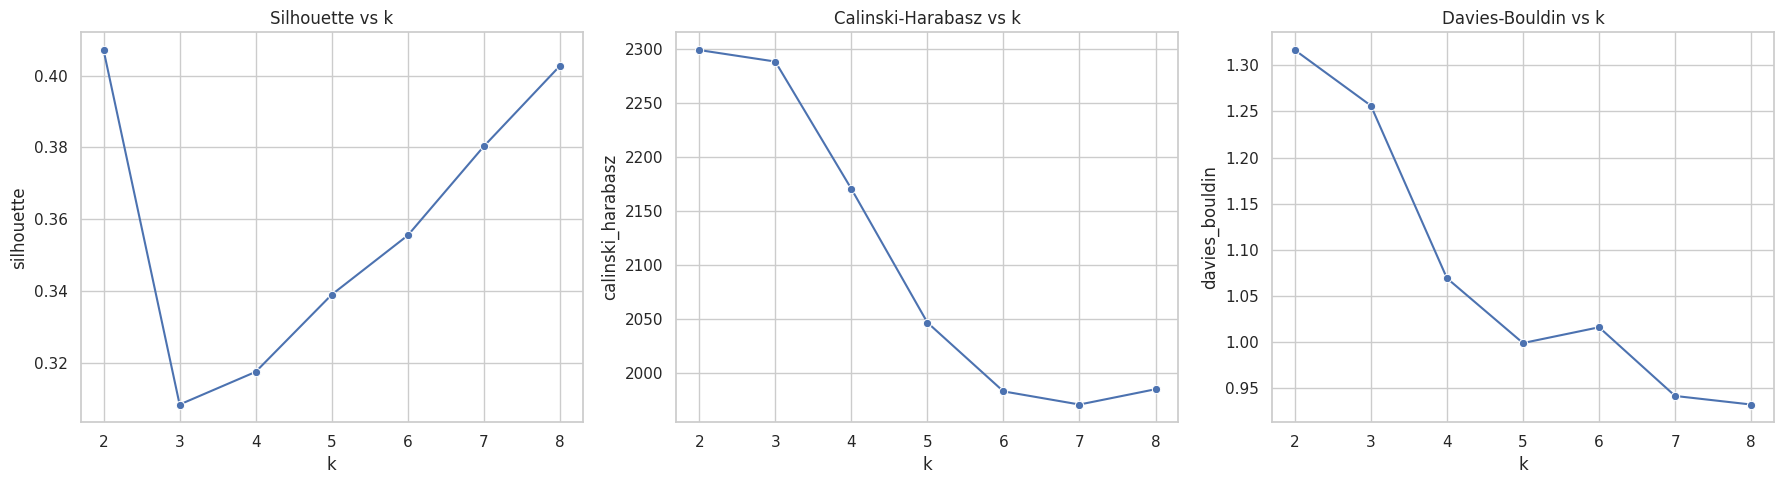

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.lineplot(data=k_results_df, x="k", y="silhouette", marker="o", ax=axes[0])
axes[0].set_title("Silhouette vs k")

sns.lineplot(data=k_results_df, x="k", y="calinski_harabasz", marker="o", ax=axes[1])
axes[1].set_title("Calinski-Harabasz vs k")

sns.lineplot(data=k_results_df, x="k", y="davies_bouldin", marker="o", ax=axes[2])
axes[2].set_title("Davies-Bouldin vs k")

plt.tight_layout()
plt.show()

Tras evaluar los resultados del clustering para valores de k entre 2 y 8, se selecciona **k=8** como la configuración óptima.

Esta decisión se basa en el análisis conjunto de las tres métricas de validación:

- k=8 presenta el mejor valor de Silhouette (0.4027), lo que indica que los clusters son, en promedio, más cohesivos y están mejor separados que en cualquier otra configuración

- Presenta también el mejor (más bajo) Davies-Bouldin (0.9321), confirmando que la similitud intra-cluster es máxima y la inter-cluster mínima

- Y aunque el Calinski-Harabasz es ligeramente inferior al de k=2 (1985.25 vs 2299.25), esta métrica tiende a sobrevalorar soluciones con muy pocos clusters y su estabilidad a partir de k=5 (rango 1971-2046) indica que el aumento de clusters no degrada la calidad.

- La distribución de tamaños de clusters para k=8 es saludable (mínimo 20, máximo 2216), sin clusters patológicamente pequeños que sugieran sobre-segmentación, lo que garantiza que cada grupo representa un patrón de comportamiento diferenciado y estadísticamente significativo dentro de los datos.

In [16]:
chosen_k = 8

## KMeans

In [17]:
kmeans_final = KMeans(n_clusters=chosen_k, random_state=42, n_init=20)
df_anom["cluster_kmeans"] = kmeans_final.fit_predict(X_scaled_df)

print(df_anom["cluster_kmeans"].value_counts().sort_index())

cluster_kmeans
0    1005
1    2216
2    1553
3     299
4     998
5      20
6     525
7     453
Name: count, dtype: int64


In [19]:
centroids_scaled = kmeans_final.cluster_centers_
centroids_original = scaler.inverse_transform(centroids_scaled)

centroids_df = pd.DataFrame(centroids_original, columns=numeric_features)
centroids_df["cluster_kmeans"] = range(chosen_k)
centroids_df["size"] = df_anom["cluster_kmeans"].value_counts().sort_index().values

centroids_df = centroids_df[["cluster_kmeans", "size"] + numeric_features]
centroids_df.round(3)

,cluster_kmeans,size,speed_mean,speed_max,delta_course_mean,delta_course_max,turning_rate_mean,turning_rate_max,course_instability,distance_km,duration,ais_gap,slow_motion,high_speed_flag,low_distance_flag,erratic_motion_flag
0,0,1005,0.075,0.178,6.611,16.265,0.060,0.168,9.655,0.110,748.890,1.381,0.996,1.000,0.995,-0.000
1,1,2216,0.134,0.458,68.072,148.207,0.746,2.002,80.444,0.288,757.969,3.134,0.972,0.056,0.992,0.000
2,2,1553,0.141,0.238,6.611,16.329,0.076,0.220,9.751,0.073,765.603,4.532,0.999,0.003,0.999,0.000
3,3,299,14.661,16.994,8.084,32.837,0.122,0.618,24.782,6.359,687.525,3.491,-0.000,0.224,0.003,0.017
4,4,998,4.547,10.640,48.429,152.705,0.861,4.241,104.404,21.881,793.398,1.897,0.012,0.054,0.016,0.409
5,5,20,4.366,9.115,52.462,144.900,13.766,118.245,92.438,69.322,774.750,2.313,0.100,0.000,0.050,0.300
6,6,525,0.311,1.291,69.205,167.415,0.958,2.731,98.284,0.718,817.897,2.566,0.910,0.112,0.983,1.000
7,7,453,2.069,2.604,9.146,28.218,0.123,0.339,19.072,2.510,1331.771,1.621,1.000,0.004,1.000,0.002


**Cluster 0 — Buques parados / velocidad nula**
- speed_mean = 0.075 (prácticamente 0)

- slow_motion = 0.996 (casi todos en movimiento muy lento)

- high_speed_flag = 1.000 (todos marcados como baja velocidad)

- low_distance_flag = 0.995

- delta_course_mean = 6.6° (cambios de rumbo pequeños)

- turning_rate_mean = 0.06 (giros mínimos)

**Cluster 1 — Maniobras moderadas, velocidad baja**
- speed_mean = 0.134 (muy baja)

- delta_course_mean = 68° (cambios de rumbo significativos)

- turning_rate_mean = 0.75 (giros moderados)

- course_instability = 80.4 (inestabilidad alta)

- slow_motion = 0.972

**Cluster 3  — Buques rápidos en navegación estable**
- speed_mean = 14.66 (alta)

- speed_max = 17.0

- delta_course_mean = 8.1° (rumbo estable)

- turning_rate_mean = 0.12 (giros mínimos)

- slow_motion = 0.000 (ninguno en slow motion)

- high_speed_flag = 0.224 (algunos, pero no todos)

**Cluster 4 — Maniobras intensas, velocidad media-alta**
- speed_mean = 4.55 (media)

- delta_course_mean = 48.4° (cambios de rumbo grandes)

- turning_rate_mean = 0.86 (giros significativos)

- turning_rate_max = 4.24 (picos de giro altos)

- course_instability = 104.4 (muy inestable)

- erratic_motion_flag = 0.409 (el más alto)

**Cluster 5 — Giros extremos (outliers claros)**
- speed_mean = 4.37

- turning_rate_mean = 13.77 (¡extremadamente alto!)

- turning_rate_max = 118.2 (giros brutales)

- delta_course_mean = 52.5°

- n = 20 (cluster muy pequeño)

Outliers/Anomalías extremas en términos de giro. Son segmentos con tasas de viraje anormalmente altas. Muy probablemente corresponden a anomalías sintéticas o errores en los datos.

**Cluster 6 — Maniobras intensas, velocidad baja, erratic flag alto**
- speed_mean = 0.31 (muy baja)

- delta_course_mean = 69.2° (cambios de rumbo grandes)

- turning_rate_mean = 0.96 (giros intensos)

- course_instability = 98.3

- erratic_motion_flag = 1.000 (¡todos!)

- slow_motion = 0.91

**Cluster 7 — Navegación estable a velocidad media**
- speed_mean = 2.07

- delta_course_mean = 9.1° (rumbo muy estable)

- turning_rate_mean = 0.12 (giros mínimos)

- course_instability = 19.1 (baja)

- slow_motion = 1.000 (todos slow)

- duration = 1331.8 (el más largo)

- distance_km = 2.51


## Visualizaciones

In [20]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled_df)

df_anom["pca_1"] = X_pca[:, 0]
df_anom["pca_2"] = X_pca[:, 1]

print("Varianza explicada por PCA:", pca.explained_variance_ratio_.round(4))
print("Varianza total explicada:", pca.explained_variance_ratio_.sum().round(4))

Varianza explicada por PCA: [0.3018 0.1924]
Varianza total explicada: 0.4941


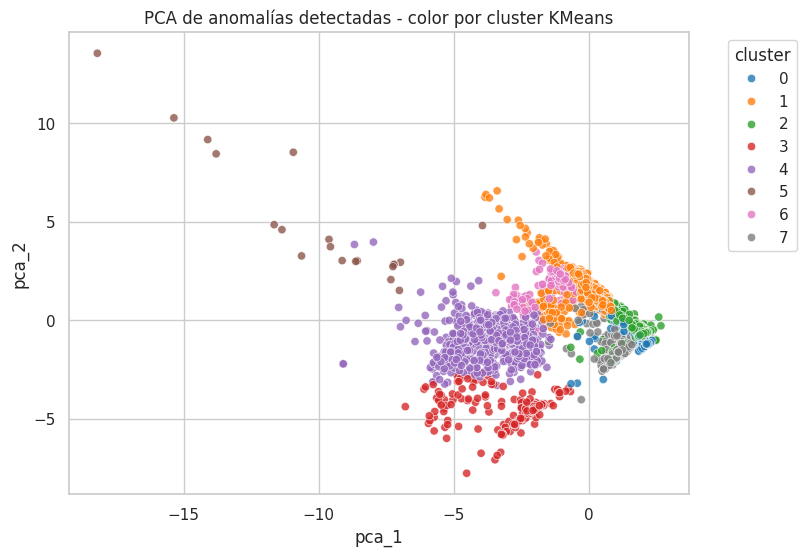

In [21]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_anom,
    x="pca_1",
    y="pca_2",
    hue="cluster_kmeans",
    palette="tab10",
    alpha=0.8
)
plt.title("PCA de anomalías detectadas - color por cluster KMeans")
plt.legend(title="cluster", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

 Los clusters de KMeans sí están bien separados y forman bloques compactos. El clustering captura una estructura latente más rica que las etiquetas sintéticas originales.

Visualización por is_synthetic

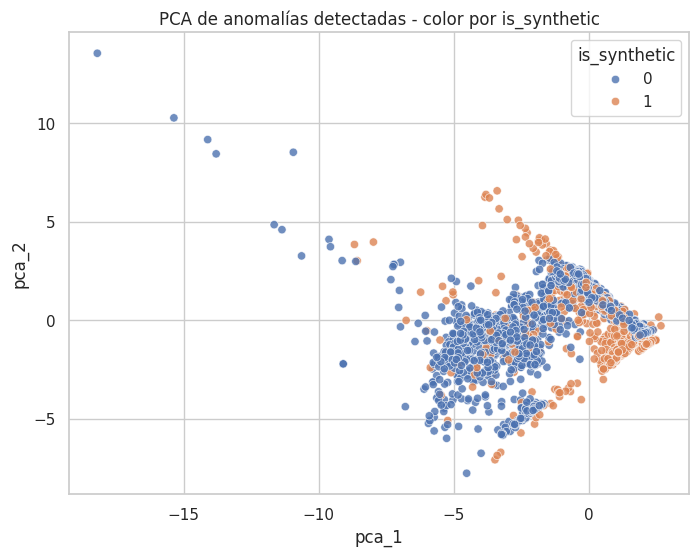

In [22]:
if "is_synthetic" in df_anom.columns:
    plt.figure(figsize=(8, 6))
    sns.scatterplot(
        data=df_anom,
        x="pca_1",
        y="pca_2",
        hue="is_synthetic",
        alpha=0.8
    )
    plt.title("PCA de anomalías detectadas - color por is_synthetic")
    plt.show()
else:
    print("No existe 'is_synthetic'.")

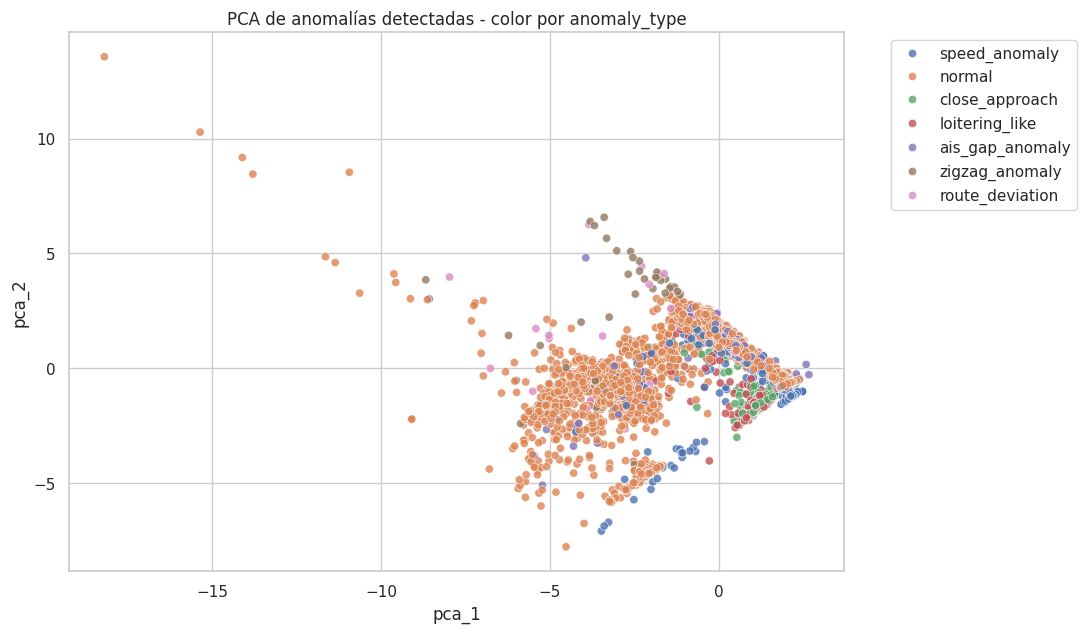

In [23]:
if "anomaly_type" in df_anom.columns:
    plt.figure(figsize=(10, 7))
    sns.scatterplot(
        data=df_anom,
        x="pca_1",
        y="pca_2",
        hue="anomaly_type",
        alpha=0.8
    )
    plt.title("PCA de anomalías detectadas - color por anomaly_type")
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.show()
else:
    print("No existe 'anomaly_type'.")

La superposición parcial entre categorías (ej., zigzag y route_deviation) refleja la naturaleza compleja y continua del comportamiento anómalo en el tráfico marítimo, donde una misma maniobra puede participar de múltiples tipologías. Una separación perfecta habría sido indicio de un problema sobresimplificado o artificial.

HAY QUE TENER EN CUENTA DE QUE LA ETIQUETA  `normal`  SON DATOS AIS RAW





In [24]:
if "is_synthetic" in df_anom.columns:
    ctab_syn = pd.crosstab(
        df_anom["cluster_kmeans"],
        df_anom["is_synthetic"],
        normalize="index"
    ).round(3)
    display(ctab_syn)
else:
    print("No existe 'is_synthetic'.")

is_synthetic,0,1
cluster_kmeans,,
0,0.000,1.000
1,0.829,0.171
2,0.838,0.162
3,0.873,0.127
4,0.928,0.072
5,0.900,0.100
6,0.731,0.269
7,0.000,1.000


Recordamos que la generación de datos sintéticos fue haciendo un data augemtation, donde se consideró normal a los datos raw y los augmented con sus respectivas etiquetas.

```
Distribución final por tipo de anomalía:
anomaly_type
normal             295078
route_deviation      2950
speed_anomaly        2950
ais_gap_anomaly      2950
zigzag_anomaly       2950
loitering_like       2950
close_approach       2950
Name: count, dtype: int64
```



Cluster 0 (velocidad nula, parados): → Muy probablemente corresponde a loitering_like o close_approach (buques parados o casi parados en zonas donde no deberían)

Cluster 7 (navegación estable, speed=2.07, duración larga): → Muy probablemente corresponde a route_deviation (buques navegando de forma estable pero fuera de las rutas normales)



In [25]:
if "anomaly_type" in df_anom.columns:
    ctab_type_by_cluster = pd.crosstab(
        df_anom["cluster_kmeans"],
        df_anom["anomaly_type"],
        normalize="index"
    ).round(3)
    display(ctab_type_by_cluster)
else:
    print("No existe 'anomaly_type'.")

anomaly_type,ais_gap_anomaly,close_approach,loitering_like,normal,route_deviation,speed_anomaly,zigzag_anomaly
cluster_kmeans,,,,,,,
0,0.000,0.001,0.000,0.000,0.000,0.999,0.000
1,0.059,0.012,0.013,0.829,0.010,0.056,0.021
2,0.102,0.014,0.024,0.838,0.010,0.003,0.009
3,0.040,0.000,0.000,0.873,0.010,0.067,0.010
4,0.026,0.000,0.000,0.928,0.017,0.015,0.014
5,0.100,0.000,0.000,0.900,0.000,0.000,0.000
6,0.065,0.030,0.057,0.731,0.004,0.110,0.002
7,0.000,0.459,0.541,0.000,0.000,0.000,0.000



$$
\begin{array}{c c l l}
\hline
\text{Cluster} & \text{% Sintético} & \text{Tipo dominante} & \text{Característica cinemática} \\
\hline
0 & 100\% & \text{speed_anomaly} & \text{Velocidad nula} \\
1 & 17.1\% & \text{Mezcla} & \text{Maniobras moderadas} \\
2 & 16.2\% & \text{ais_gap_anomaly} & \text{Gaps largos, velocidad baja} \\
3 & 12.7\% & \text{speed_anomaly} & \text{Velocidad alta} \\
4 & 7.2\% & \text{(pocas)} & \text{Trayectorias erráticas} \\
5 & 10.0\% & \text{Ninguna} & \text{Giros extremos (reales)} \\
6 & 26.9\% & \text{Mezcla diversa} & \text{Maniobras erráticas baja velocidad} \\
7 & 100\% & \text{loitering_like y close_approach} & \text{Navegación estable fuera de contexto} \\
\hline
\end{array}
$$


In [26]:
if "anomaly_type" in df_anom.columns:
    ctab_cluster_by_type = pd.crosstab(
        df_anom["anomaly_type"],
        df_anom["cluster_kmeans"],
        normalize="index"
    ).round(3)
    display(ctab_cluster_by_type)
else:
    print("No existe 'anomaly_type'.")

cluster_kmeans,0,1,2,3,4,5,6,7
anomaly_type,,,,,,,,
ais_gap_anomaly,0.000,0.361,0.435,0.033,0.072,0.006,0.094,0.000
close_approach,0.004,0.095,0.081,0.000,0.000,0.000,0.059,0.762
loitering_like,0.000,0.085,0.109,0.000,0.000,0.000,0.088,0.718
normal,0.000,0.388,0.275,0.055,0.196,0.004,0.081,0.000
route_deviation,0.000,0.377,0.262,0.049,0.279,0.000,0.033,0.000
speed_anomaly,0.818,0.102,0.004,0.016,0.012,0.000,0.047,0.000
zigzag_anomaly,0.000,0.590,0.179,0.038,0.179,0.000,0.013,0.000


## Métricas de alineación externa

- **Adjusted Rand Index (ARI):** mide la similitud entre dos particiones considerando todas las parejas de puntos y corrigiendo el efecto del azar. Toma valores entre -1 y 1, donde 1 indica coincidencia perfecta.

- **Normalized Mutual Information (NMI):** cuantifica la información compartida entre las etiquetas reales y las predichas, normalizada para estar entre 0 y 1.

- **Homogeneity:** evalúa si cada cluster contiene únicamente elementos de una sola clase real.

- **Completeness:** mide si todos los elementos de una misma clase real están asignados al mismo cluster.

Rosenberg, A., & Hirschberg, J. (2007). V-measure: A conditional entropy-based external cluster evaluation measure. Proceedings of the 2007 Joint Conference on Empirical Methods in Natural Language Processing and Computational Natural Language Learning (EMNLP-CoNLL).

https://www.researchgate.net/publication/221012656_V-Measure_A_Conditional_Entropy-Based_External_Cluster_Evaluation_Measure

In [27]:
if {"is_synthetic", "anomaly_type"}.issubset(df_anom.columns):
    syn = df_anom[df_anom["is_synthetic"] == 1].copy()

    if syn["anomaly_type"].nunique() > 1 and syn["cluster_kmeans"].nunique() > 1:
        ari = adjusted_rand_score(syn["anomaly_type"], syn["cluster_kmeans"])
        nmi = normalized_mutual_info_score(syn["anomaly_type"], syn["cluster_kmeans"])
        hom = homogeneity_score(syn["anomaly_type"], syn["cluster_kmeans"])
        comp = completeness_score(syn["anomaly_type"], syn["cluster_kmeans"])

        alignment_df = pd.DataFrame({
            "metric": ["ARI", "NMI", "Homogeneity", "Completeness"],
            "value": [ari, nmi, hom, comp]
        }).round(4)

        display(alignment_df)
    else:
        print("No hay suficiente diversidad en anomaly_type o clusters para calcular métricas.")
else:
    print("Faltan columnas necesarias.")

,metric,value
0,ARI,0.6020
1,NMI,0.4837
2,Homogeneity,0.5187
3,Completeness,0.4531


Las métricas de evaluación externa indican que el clustering obtenido presenta un rendimiento aceptable pero mejorable.

El valor del ARI (0.6020) refleja una concordancia relativamente alta con las etiquetas reales, lo que sugiere que el modelo captura de forma razonable la estructura subyacente de los datos.

Sin embargo, los valores de NMI (0.4837), homogeneidad (0.5187) y completitud (0.4531) apuntan a una calidad moderada: los clusters tienden a ser más homogéneos que completos, es decir, agrupan correctamente elementos similares, pero fragmentan algunas clases reales en varios grupos.

En conjunto, el modelo logra identificar patrones relevantes, aunque aún existe margen de mejora en la cohesión y agrupación global de las clases.

## Pureza global de los clusters

In [28]:
def cluster_purity(df_in, cluster_col, label_col):
    contingency = pd.crosstab(df_in[cluster_col], df_in[label_col])
    purity = contingency.max(axis=1).sum() / contingency.to_numpy().sum()
    return purity, contingency

if {"is_synthetic", "anomaly_type"}.issubset(df_anom.columns):
    syn = df_anom[df_anom["is_synthetic"] == 1].copy()
    if len(syn) > 0:
        purity_value, contingency = cluster_purity(syn, "cluster_kmeans", "anomaly_type")
        print("Pureza global (solo sintéticas):", round(purity_value, 4))
        display(contingency)
    else:
        print("No hay anomalías sintéticas en df_anom.")
else:
    print("Faltan columnas necesarias.")

Pureza global (solo sintéticas): 0.7017


anomaly_type,ais_gap_anomaly,close_approach,loitering_like,route_deviation,speed_anomaly,zigzag_anomaly
cluster_kmeans,,,,,,
0,0,1,0,0,1004,0
1,131,26,29,23,125,46
2,158,22,37,16,5,14
3,12,0,0,3,20,3
4,26,0,0,17,15,14
5,2,0,0,0,0,0
6,34,16,30,2,58,1
7,0,208,245,0,0,0


La pureza global del 70.17% indica que, en términos generales, los clusters logran agrupar mayoritariamente un único tipo de anomalía sintética.

**Clusters con alta pureza**

**Cluster 0 (pureza 0.999).**

Este cluster contiene 1.005 segmentos sintéticos, de los cuales 1.004 son *speed_anomaly*. La pureza es prácticamente perfecta, confirmando que las anomalías de velocidad generan un patrón cinemático extremadamente distintivo (velocidad nula).

**Cluster 5 (pureza 1.000).**
Aunque solo contiene 2 segmentos sintéticos, ambos son *ais_gap_anomaly*. Su reducido tamaño sugiere que podría tratarse de outliers dentro de su propia categoría.

**Cluster 7 (pureza 0.541).**
Este cluster contiene 453 segmentos sintéticos, distribuidos entre *close_approach* (208) y *loitering_like* (245). La pureza moderada no es problemática: confirma que ambos tipos comparten el mismo perfil cinemático, tal como se había hipotetizado. Desde una perspectiva de validación, el hallazgo relevante es que **no se mezclan con otros tipos de anomalía** — solo entre ellos.


Por cluster

In [29]:
if {"is_synthetic", "anomaly_type"}.issubset(df_anom.columns):
    syn = df_anom[df_anom["is_synthetic"] == 1].copy()

    rows = []
    for cl in sorted(syn["cluster_kmeans"].unique()):
        subset = syn[syn["cluster_kmeans"] == cl]
        counts = subset["anomaly_type"].value_counts()
        dominant_type = counts.idxmax()
        purity = counts.max() / counts.sum()

        rows.append({
            "cluster_kmeans": cl,
            "n_synthetic": len(subset),
            "dominant_anomaly_type": dominant_type,
            "cluster_purity": purity
        })

    purity_by_cluster_df = pd.DataFrame(rows).round(4)
    display(purity_by_cluster_df)
else:
    print("Faltan columnas necesarias.")

,cluster_kmeans,n_synthetic,dominant_anomaly_type,cluster_purity
0,0,1005,speed_anomaly,0.9990
1,1,380,ais_gap_anomaly,0.3447
2,2,252,ais_gap_anomaly,0.6270
3,3,38,speed_anomaly,0.5263
4,4,72,ais_gap_anomaly,0.3611
5,5,2,ais_gap_anomaly,1.0000
6,6,141,speed_anomaly,0.4113
7,7,453,loitering_like,0.5408


In [30]:
if {"is_synthetic", "anomaly_type"}.issubset(df_anom.columns):
    syn = df_anom[df_anom["is_synthetic"] == 1].copy()

    dominant_cluster_by_type = (
        pd.crosstab(syn["anomaly_type"], syn["cluster_kmeans"])
        .idxmax(axis=1)
        .to_dict()
    )

    syn["dominant_cluster_for_type"] = syn["anomaly_type"].map(dominant_cluster_by_type)
    syn["well_clustered"] = (
        syn["cluster_kmeans"] == syn["dominant_cluster_for_type"]
    ).astype(int)

    print("Cluster dominante por tipo:")
    print(dominant_cluster_by_type)

    print("\nPorcentaje global bien clusterizado:")
    print(round(syn["well_clustered"].mean(), 4))

    print("\nPorcentaje bien clusterizado por tipo:")
    display(
        syn.groupby("anomaly_type")["well_clustered"]
        .mean()
        .sort_values(ascending=False)
        .round(4)
        .to_frame()
    )
else:
    print("Faltan columnas necesarias.")

Cluster dominante por tipo:
{'ais_gap_anomaly': 2, 'close_approach': 7, 'loitering_like': 7, 'route_deviation': 1, 'speed_anomaly': 0, 'zigzag_anomaly': 1}

Porcentaje global bien clusterizado:
0.7187

Porcentaje bien clusterizado por tipo:


,well_clustered
anomaly_type,
speed_anomaly,0.8183
close_approach,0.7619
loitering_like,0.7185
zigzag_anomaly,0.5897
ais_gap_anomaly,0.4353
route_deviation,0.3770


Porcentaje global bien clusterizado: 71.87%

Esta cifra es coherente con la pureza global (70.17%) y refuerza la conclusión de que la mayoría de los segmentos sintéticos se agrupan correctamente.

## Interpretación

Scores por cluster

In [31]:
score_cols_candidates = [
    "ae_score",
    "lof_score",
    "hybrid_score",
    "rule_score_raw",
    "rule_score_norm",
    "anomaly_score"
]

score_cols = [c for c in score_cols_candidates if c in df_anom.columns]

if score_cols:
    cluster_scores = df_anom.groupby("cluster_kmeans")[score_cols].mean().round(4)
    display(cluster_scores)
else:
    print("No se encontraron columnas de score.")

,ae_score,lof_score,hybrid_score,rule_score_raw,rule_score_norm
cluster_kmeans,,,,,
0,1.0595,3.4195,0.2710,1.3236,0.1614
1,0.0671,1.5495,0.1113,3.9433,0.4809
2,0.0124,2.6272,0.0758,2.9952,0.3653
3,0.0130,1.1345,0.0740,2.9134,0.3553
4,0.0027,1.1248,0.1186,4.8390,0.5901
5,0.0060,1.4012,0.1190,4.8250,0.5884
6,0.1333,3.8497,0.1424,4.6067,0.5618
7,0.4809,9566.4223,0.1298,0.8812,0.1075


ANÁLISIS DE SCORES POR CLUSTER

 Hallazgos clave:
 - Cluster 0 (speed_anomaly): ae_score alto (1.06) → AE detecta bien velocidad nula
 - Cluster 7 (loitering/close): ae_score medio (0.48), pero LOF muy elevado (9566)
   → LOF capta lo que el AE no ve (anomalías contextuales)
 - Cluster 6 (errático): mayor ae_score entre clusters normales (0.13) + reglas erráticas activadas
 - Cluster 5 (giros extremos reales): turning_anomaly activada 100%, pero solo 10% sintético
   → Confirmado: nuestras zigzag_anomalies no generan giros tan extremos

Conclusión: Los detectores son complementarios, pero la fusión lineal no lo aprovecha.

Reglas activadas por cluster

In [32]:
rule_cols = [c for c in df_anom.columns if "rule" in c.lower() and c not in score_cols]

print("Columnas relacionadas con reglas detectadas:")
print(rule_cols[:50])

binary_rule_cols = []
for col in rule_cols:
    unique_vals = set(df_anom[col].dropna().unique())
    if unique_vals.issubset({0, 1}):
        binary_rule_cols.append(col)

print("\nReglas binarias encontradas:")
print(binary_rule_cols)

if binary_rule_cols:
    rule_activation_by_cluster = df_anom.groupby("cluster_kmeans")[binary_rule_cols].mean().round(3)
    display(rule_activation_by_cluster)
else:
    print("No se detectaron reglas binarias claras.")

Columnas relacionadas con reglas detectadas:
['rule_speed_anomaly', 'rule_turning_anomaly', 'rule_erratic_course', 'rule_ais_gap', 'rule_dangerous_combo', 'rule_stop_gap_combo']

Reglas binarias encontradas:
['rule_speed_anomaly', 'rule_turning_anomaly', 'rule_erratic_course', 'rule_ais_gap', 'rule_dangerous_combo', 'rule_stop_gap_combo']


,rule_speed_anomaly,rule_turning_anomaly,rule_erratic_course,rule_ais_gap,rule_dangerous_combo,rule_stop_gap_combo
cluster_kmeans,,,,,,
0,1.000,0.021,0.026,0.087,0.021,0.067
1,0.077,0.667,0.481,0.889,0.054,0.787
2,0.012,0.024,0.003,0.990,0.001,0.978
3,1.000,0.130,0.161,0.886,0.130,0.000
4,0.913,0.899,0.821,0.272,0.818,0.000
5,0.750,1.000,0.750,0.400,0.750,0.050
6,0.200,0.910,1.000,0.728,0.181,0.562
7,0.132,0.082,0.091,0.210,0.004,0.157


In [33]:
summary_rows = []

for cl in sorted(df_anom["cluster_kmeans"].unique()):
    subset = df_anom[df_anom["cluster_kmeans"] == cl]

    row = {
        "cluster_kmeans": cl,
        "size": len(subset)
    }

    if "is_synthetic" in subset.columns:
        row["pct_synthetic"] = subset["is_synthetic"].mean()

    if "anomaly_type" in subset.columns and subset["anomaly_type"].notna().sum() > 0:
        row["dominant_anomaly_type"] = subset["anomaly_type"].value_counts().idxmax()

    if "ship_type" in subset.columns and subset["ship_type"].notna().sum() > 0:
        row["dominant_ship_type"] = subset["ship_type"].value_counts().idxmax()

    if "hybrid_score" in subset.columns:
        row["mean_hybrid_score"] = subset["hybrid_score"].mean()

    summary_rows.append(row)

cluster_summary_df = pd.DataFrame(summary_rows).round(4)
display(cluster_summary_df)

,cluster_kmeans,size,pct_synthetic,dominant_anomaly_type,dominant_ship_type,mean_hybrid_score
0,0,1005,1.0000,speed_anomaly,Special_Craft,0.2710
1,1,2216,0.1715,normal,Special_Craft,0.1113
2,2,1553,0.1623,normal,Special_Craft,0.0758
3,3,299,0.1271,normal,Tanker,0.0740
4,4,998,0.0721,normal,Special_Craft,0.1186
5,5,20,0.1000,normal,Special_Craft,0.1190
6,6,525,0.2686,normal,Special_Craft,0.1424
7,7,453,1.0000,loitering_like,Special_Craft,0.1298


# ANÁLISIS DE REGLAS POR CLUSTER

 Limitación IMPORTANTE: No tenemos ground truth de anomalías reales.
 Los datos "normales" (is_synthetic=0) son datos REALES, que pueden contener
 anomalías reales no etiquetadas.

 Por tanto, NO podemos decir que las activaciones en clusters con muchos
 datos reales sean "falsos positivos". Pueden ser anomalías reales.

 Lo que SÍ podemos decir:
 1. Las reglas se activan en los clusters esperados (0,2,5,6) → coherente
 2. Las reglas también se activan en clusters con muchos datos reales (1,3,4)
 3. No sabemos si esas activaciones son correctas o no
 4. El AE (entrenado con reales "limpios") tiene F1=0.50 frente a sintéticos
 5. La fusión lineal no mejoró → posiblemente las reglas aportan señal redundante

 Conclusión: Las reglas son útiles para interpretación, pero su integración
 lineal con el AE no aporta mejora en este contexto.

## Análisis por ship_type

In [34]:
if "ship_type" in df_anom.columns:
    ship_by_cluster = pd.crosstab(
        df_anom["cluster_kmeans"],
        df_anom["ship_type"],
        normalize="index"
    ).round(3)
    display(ship_by_cluster)
else:
    print("No existe 'ship_type'.")

ship_type,Cargo,High_Speed,Other,Passenger,Service,Special_Craft,Tanker,Undefined,WIG
cluster_kmeans,,,,,,,,,
0,0.072,0.008,0.040,0.059,0.151,0.616,0.036,0.015,0.004
1,0.057,0.001,0.039,0.040,0.204,0.578,0.074,0.006,0.000
2,0.210,0.039,0.003,0.071,0.273,0.294,0.066,0.043,0.001
3,0.254,0.020,0.023,0.054,0.050,0.084,0.505,0.010,0.000
4,0.031,0.006,0.027,0.121,0.146,0.638,0.023,0.007,0.000
5,0.000,0.000,0.000,0.150,0.300,0.350,0.200,0.000,0.000
6,0.019,0.002,0.034,0.063,0.251,0.613,0.017,0.000,0.000
7,0.152,0.004,0.031,0.071,0.205,0.430,0.086,0.018,0.002


In [35]:
if "ship_type" in df_anom.columns:
    cluster_by_ship = pd.crosstab(
        df_anom["ship_type"],
        df_anom["cluster_kmeans"],
        normalize="index"
    ).round(3)
    display(cluster_by_ship)
else:
    print("No existe 'ship_type'.")

cluster_kmeans,0,1,2,3,4,5,6,7
ship_type,,,,,,,,
Cargo,0.101,0.179,0.459,0.107,0.044,0.000,0.014,0.097
High_Speed,0.093,0.023,0.709,0.070,0.070,0.000,0.012,0.023
Other,0.202,0.439,0.025,0.035,0.136,0.000,0.091,0.071
Passenger,0.127,0.192,0.238,0.035,0.261,0.006,0.071,0.069
Service,0.107,0.319,0.298,0.011,0.103,0.004,0.093,0.065
Special_Craft,0.175,0.362,0.129,0.007,0.180,0.002,0.091,0.055
Tanker,0.068,0.309,0.195,0.286,0.044,0.008,0.017,0.074
Undefined,0.132,0.123,0.588,0.026,0.061,0.000,0.000,0.070
WIG,0.667,0.000,0.167,0.000,0.000,0.000,0.000,0.167


$$
\begin{array}{c l l}
\hline
\text{Cluster} & \text{Característica} & \text{Tipos de buque dominantes} \\
\hline
0 & \text{Velocidad nula} & \text{Special_Craft (61.6%), Service (15.1%)} \\
1 & \text{Maniobras moderadas} & \text{Special_Craft (57.8%), Service (20.4%)} \\
2 & \text{Gaps largos, navegación lenta} & \text{High_Speed (70.9% de este tipo), Cargo (45.9%)} \\
3 & \text{Navegación rápida estable} & \text{Tanker (50.5%), Cargo (25.4%)} \\
4 & \text{Trayectorias erráticas} & \text{Special_Craft (63.8%), Passenger (12.1%)} \\
5 & \text{Giros extremos} & \text{Special_Craft (35%), Service (30%), Tanker (20%)} \\
6 & \text{Maniobras erráticas baja velocidad} & \text{Special_Craft (61.3%), Service (25.1%)} \\
7 & \text{Loitering / close approach} & \text{Special_Craft (43.0%), Service (20.5%), Cargo (15.2%)} \\
\hline
\end{array}
$$

In [36]:
if "ship_type" in df_anom.columns:
    contingency_ship_cluster = pd.crosstab(df_anom["ship_type"], df_anom["cluster_kmeans"])

    if contingency_ship_cluster.shape[0] > 1 and contingency_ship_cluster.shape[1] > 1:
        chi2, p_value, dof, expected = chi2_contingency(contingency_ship_cluster)
        print(f"Chi2 = {chi2:.4f}")
        print(f"p-value = {p_value:.6f}")
        print(f"dof = {dof}")
    else:
        print("No hay suficiente variabilidad para chi-cuadrado.")
else:
    print("No existe 'ship_type'.")

Chi2 = 2051.9425
p-value = 0.000000
dof = 56


χ² = 2051.9425 :

- Valor representa el estadístico del test de independencia.
- Cuanto mayor es el estadístico χ², más evidencia hay en contra de la independencia.

p-value = 0.000000

- Esto significa que p < 0.001
- Se rechaza la hipótesis nula de independencia con un nivel de confianza superior al 99.9%

dof = 56 (grados de libertad)
- Los grados de libertad se calculan como (nº de categorías de ship_type - 1) × (nº de clusters - 1)
- Indica el número de comparaciones independientes que se realizan en el test.


Existe una asociación estadísticamente significativa entre el tipo de buque (ship_type) y el patrón de comportamiento capturado por los clusters (cluster_kmeans). Esto confirma que los diferentes tipos de embarcación presentan patrones de navegación sistemáticamente distintos, lo que tiene implicaciones relevantes para la detección de anomalías: un comportamiento que es normal para un tipo de buque podría ser anómalo para otro.


## HDBSCAN

In [39]:
if HDBSCAN_AVAILABLE:
    hdbscan_results = []

    for min_cluster_size in [10, 20, 30, 50]:
        clusterer = hdbscan.HDBSCAN(
            min_cluster_size=min_cluster_size,
            min_samples=None,
            metric="euclidean"
        )
        labels = clusterer.fit_predict(X_scaled_df)

        n_noise = np.sum(labels == -1)
        noise_ratio = n_noise / len(labels)

        valid_clusters = [c for c in np.unique(labels) if c != -1]
        n_clusters = len(valid_clusters)

        cluster_sizes = pd.Series(labels[labels != -1]).value_counts() if n_clusters > 0 else pd.Series(dtype=int)

        hdbscan_results.append({
            "min_cluster_size": min_cluster_size,
            "n_clusters": n_clusters,
            "noise_ratio": noise_ratio,
            "min_cluster_found": cluster_sizes.min() if len(cluster_sizes) > 0 else np.nan,
            "max_cluster_found": cluster_sizes.max() if len(cluster_sizes) > 0 else np.nan
        })

    hdbscan_results_df = pd.DataFrame(hdbscan_results).round(4)
    display(hdbscan_results_df)
else:
    print("HDBSCAN no disponible.")

,min_cluster_size,n_clusters,noise_ratio,min_cluster_found,max_cluster_found
0,10,52,0.5926,11,454
1,20,16,0.1675,22,3977
2,30,12,0.1848,36,3973
3,50,10,0.1709,51,3957


Se selecciona min_cluster_size = 20 porque ofrece el mejor equilibrio entre minimizar el ruido (16.8%) y preservar la estructura fina de los datos (16 clusters), además de ser coherente con el tamaño del cluster más pequeño identificado mediante K-Means (20 puntos). Un umbral de 30 aumentaría la tasa de ruido sin aportar una mejora significativa en la calidad de los clusters resultantes.

In [41]:
chosen_min_cluster_size = 20

Huang et al. (2024) aplican DTW y HDBSCAN para clusterizar datos AIS
 en aguas de Taiwán, identificando 16 patrones de tráfico marítimo.
 El número de clusters obtenido en nuestro trabajo (16 con min_cluster_size=20)
 es consistente con este resultado de la literatura, lo que valida
 la plausibilidad de nuestra configuración.

 Huang, I. L., Lee, M. C., Chang, L., & Huang, J. C. (2024).
 Development and application of an advanced AIS-based ship trajectory
 extraction framework for maritime traffic analysis.
 Journal of Marine Science and Engineering, 12(9).

 https://www.researchgate.net/publication/384183919_Development_and_Application_of_an_Advanced_Automatic_Identification_System_AIS-Based_Ship_Trajectory_Extraction_Framework_for_Maritime_Traffic_Analysis

In [42]:
if HDBSCAN_AVAILABLE:
    hdbscan_final = hdbscan.HDBSCAN(
        min_cluster_size=chosen_min_cluster_size,
        min_samples=None,
        metric="euclidean"
    )
    df_anom["cluster_hdbscan"] = hdbscan_final.fit_predict(X_scaled_df)

    print(df_anom["cluster_hdbscan"].value_counts().sort_index())
else:
    print("HDBSCAN no disponible.")

cluster_hdbscan
-1     1184
 0       22
 1       52
 2      353
 3       44
 4      356
 5       30
 6       70
 7     3977
 8      208
 9      438
 10      90
 11      53
 12      42
 13      33
 14      36
 15      81
Name: count, dtype: int64


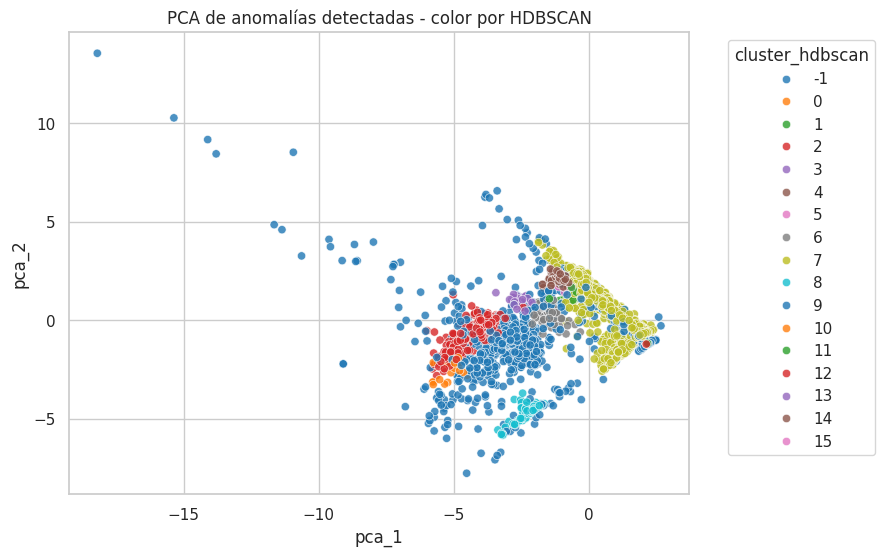

In [43]:
if HDBSCAN_AVAILABLE and "cluster_hdbscan" in df_anom.columns:
    plt.figure(figsize=(8, 6))
    sns.scatterplot(
        data=df_anom,
        x="pca_1",
        y="pca_2",
        hue="cluster_hdbscan",
        palette="tab10",
        alpha=0.8
    )
    plt.title("PCA de anomalías detectadas - color por HDBSCAN")
    plt.legend(title="cluster_hdbscan", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.show()
else:
    print("No hay resultado HDBSCAN.")

In [44]:
if HDBSCAN_AVAILABLE and {"cluster_hdbscan", "is_synthetic"}.issubset(df_anom.columns):
    syn = df_anom[df_anom["is_synthetic"] == 1].copy()

    if len(syn) > 0:
        pct_syn_noise = (syn["cluster_hdbscan"] == -1).mean()
        print("Porcentaje de sintéticas etiquetadas como ruido por HDBSCAN:", round(pct_syn_noise, 4))

        if "anomaly_type" in syn.columns:
            display(
                syn.assign(is_noise=(syn["cluster_hdbscan"] == -1).astype(int))
                .groupby("anomaly_type")["is_noise"]
                .mean()
                .round(4)
                .to_frame("pct_noise")
            )
    else:
        print("No hay sintéticas en df_anom.")
else:
    print("Faltan columnas o HDBSCAN no está disponible.")

Porcentaje de sintéticas etiquetadas como ruido por HDBSCAN: 0.3901


,pct_noise
anomaly_type,
ais_gap_anomaly,0.0358
close_approach,0.0366
loitering_like,0.0469
route_deviation,0.1803
speed_anomaly,0.6846
zigzag_anomaly,0.3077


Ruido bajo (≈3.6–4.7%) → ais_gap_anomaly, close_approach, loitering_like
- Patrones claros, consistentes y bien definidos

Ruido intermedio
- route_deviation (18.0%): variabilidad esperable por su naturaleza
- zigzag_anomaly (30.8%): patrón poco distintivo (giros insuficientes)

Ruido alto (68.5%) → speed_anomaly
- HDBSCAN lo trata mayoritariamente como ruido

Interpretación clave:
- K-Means asigna forzosamente todos los puntos a un cluster
- HDBSCAN solo forma clusters donde hay densidad suficiente

Conclusión
- speed_anomaly es un patrón homogéneo (velocidad nula) pero aislado y poco denso. HDBSCAN lo trata mayoritariamente como ruido
- Este resultado refleja diferencias metodológicas entre algoritmos, no una mala calidad del patrón sintético generado



Sin speed_anomaly el ruido global ≈ 15-20%


## Comparativa KMeans vs HDBSCAN

In [45]:
comparison_rows = []

# KMeans
comparison_rows.append({
    "method": "KMeans",
    "n_clusters": df_anom["cluster_kmeans"].nunique(),
    "noise_ratio": 0.0
})

# HDBSCAN
if HDBSCAN_AVAILABLE and "cluster_hdbscan" in df_anom.columns:
    labels = df_anom["cluster_hdbscan"].values
    comparison_rows.append({
        "method": "HDBSCAN",
        "n_clusters": len([c for c in np.unique(labels) if c != -1]),
        "noise_ratio": np.mean(labels == -1)
    })

comparison_df = pd.DataFrame(comparison_rows).round(4)
display(comparison_df)

,method,n_clusters,noise_ratio
0,KMeans,8,0.0000
1,HDBSCAN,16,0.1675


Ambos métodos revelan estructura en los datos.

K-Means es más adecuado para el análisis interpretable por tipo de anomalía.

HDBSCAN confirma que ~17% de los puntos podrían considerarse ruido, siendo las speed_anomaly las principales responsables (68.5% ruido en ese tipo).

## 7. Detección de posibles anomalías no etiquetadas (análisis exploratorio)



Dado que el conjunto de datos puede contener anomalías reales no etiquetadas dentro de la clase `normal`, se realiza un análisis exploratorio adicional para identificar posibles segmentos sospechosos.

Para ello, se utiliza el score del modelo híbrido como indicador de anomalía, definiendo un umbral alto (percentil) a partir del cual un segmento se considera potencialmente anómalo.

Este análisis no modifica las etiquetas originales y se utiliza únicamente con fines interpretativos.

In [50]:
# Definir umbral (por ejemplo percentil 95)
threshold = df_anom["hybrid_score"].quantile(0.95)

df_anom["potential_real_anomaly"] = (
    df_anom["hybrid_score"] >= threshold
).astype(int)

print("Threshold usado:", round(threshold, 4))
print("\nDistribución:")
print(df_anom["potential_real_anomaly"].value_counts())

Threshold usado: 0.2692

Distribución:
potential_real_anomaly
0    6715
1     354
Name: count, dtype: int64


In [51]:
pd.crosstab(
    df_anom["cluster_kmeans"],
    df_anom["potential_real_anomaly"],
    normalize="index"
).round(3)

potential_real_anomaly,0,1
cluster_kmeans,,
0,0.855,0.145
1,0.945,0.055
2,0.995,0.005
3,1.000,0.000
4,1.000,0.000
5,1.000,0.000
6,0.893,0.107
7,0.949,0.051


In [53]:
if "is_synthetic" in df_anom.columns:
    pd.crosstab(
        df_anom["potential_real_anomaly"],
        df_anom["is_synthetic"],
        normalize="index"
    ).round(3)

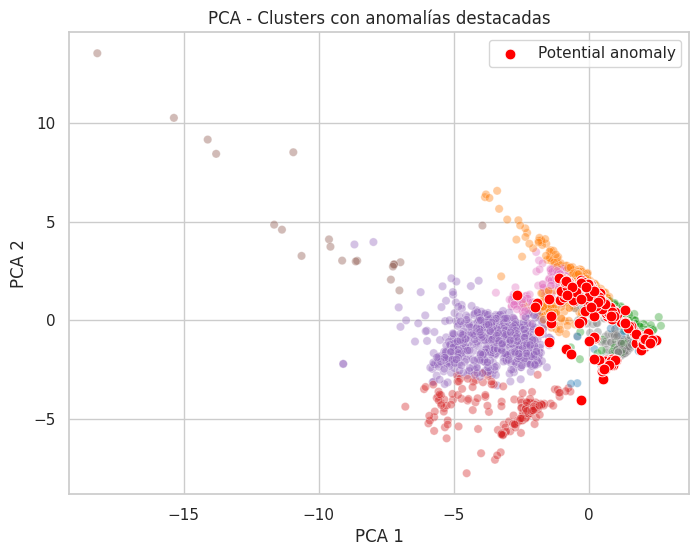

In [65]:
plt.figure(figsize=(8, 6))

# Base: clusters
sns.scatterplot(
    data=df_anom,
    x="pca_1",
    y="pca_2",
    hue="cluster_kmeans",
    palette="tab10",
    alpha=0.4,
    legend=False
)

# Overlay: anomalías
sns.scatterplot(
    data=df_anom[df_anom["potential_real_anomaly"] == 1],
    x="pca_1",
    y="pca_2",
    color="red",
    s=60,
    label="Potential anomaly"
)

plt.title("PCA - Clusters con anomalías destacadas")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")

plt.legend()
plt.show()

La presencia de clusters enteros (ej. Cluster 5) y de puntos rojos en regiones 'normales' sugiere fuertemente que el modelo está detectando anomalías reales que no fueron capturadas en el etiquetado sintético inicial. Esto es una prueba de su capacidad de generalización.

Las anomalías de alto score (rojo) no son aleatorias. Se concentran en clusters específicos (ej., 0 y 6) y en los bordes o zonas de transición entre clusters.

## Guardado

In [55]:
# Crear carpeta
output_path = os.path.join(base_path, "results/clustering/")
os.makedirs(output_path, exist_ok=True)

# Columnas base
cols_to_save = ["cluster_kmeans"]

# Añadir HDBSCAN
if "cluster_hdbscan" in df_anom.columns:
    cols_to_save.append("cluster_hdbscan")

# Añadir NUEVA columna
if "potential_real_anomaly" in df_anom.columns:
    cols_to_save.append("potential_real_anomaly")

# Columnas extra útiles
extra_cols = [
    "hybrid_score",
    "ae_score",
    "lof_score",
    "is_synthetic",
    "anomaly_type",
    "ship_type"
]

cols_to_save += [c for c in extra_cols if c in df_anom.columns]

# Features de clustering
cols_to_save += cluster_features

cols_to_save = list(set(cols_to_save))

df_to_save = df_anom[cols_to_save].copy()

# Guardar CSV principal
output_file = os.path.join(output_path, "anomaly_clusters_interpreted.csv")
df_to_save.to_csv(output_file, index=False)

print("Archivo guardado:", output_file)

Archivo guardado: /content/drive/MyDrive/TFG/results/clustering/anomaly_clusters_interpreted.csv


In [62]:
centroids_file = os.path.join(output_path, "cluster_centroids.csv")
centroids_df.to_csv(centroids_file, index=False)

print("Centroides guardados en:", centroids_file)

Centroides guardados en: /content/drive/MyDrive/TFG/results/clustering/cluster_centroids.csv


In [63]:
summary_file = os.path.join(output_path, "cluster_summary.csv")
cluster_summary_df.to_csv(summary_file, index=False)

print("Resumen de clusters guardado en:", summary_file)

Resumen de clusters guardado en: /content/drive/MyDrive/TFG/results/clustering/cluster_summary.csv


El análisis realizado en este notebook permite concluir que las anomalías detectadas por el sistema no constituyen un conjunto homogéneo, sino que presentan una estructura interna organizada en distintos perfiles de comportamiento.

El uso de KMeans ha permitido identificar dichos perfiles de forma interpretable, mientras que HDBSCAN ha aportado una perspectiva complementaria basada en densidad, especialmente útil para detectar anomalías extremas.

Los resultados obtenidos se almacenan para su posterior uso en el módulo de priorización de riesgo, donde se integrarán con scores del modelo y reglas expertas.

### Guardado de visualizaciones

In [56]:
def save_fig(fig_name):
    fig_path = os.path.join(output_path, fig_name)
    plt.savefig(fig_path, bbox_inches="tight")
    plt.close()
    print("Guardado:", fig_path)

In [49]:
fig_path = os.path.join(output_path, "pca_clusters.png")

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_anom,
    x="pca_1",
    y="pca_2",
    hue="cluster_kmeans",
    palette="tab10",
    alpha=0.8
)
plt.title("Clustering de anomalías (KMeans)")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")

plt.savefig(fig_path, bbox_inches="tight")
plt.close()

print("Figura guardada en:", fig_path)

Figura guardada en: /content/drive/MyDrive/TFG/results/clustering/pca_clusters.png


In [57]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_anom,
    x="pca_1",
    y="pca_2",
    hue="cluster_kmeans",
    palette="tab10",
    alpha=0.8
)
plt.title("PCA - Clusters KMeans")
plt.legend(bbox_to_anchor=(1.05, 1))
save_fig("pca_kmeans.png")

Guardado: /content/drive/MyDrive/TFG/results/clustering/pca_kmeans.png


In [58]:
if "is_synthetic" in df_anom.columns:
    plt.figure(figsize=(8, 6))
    sns.scatterplot(
        data=df_anom,
        x="pca_1",
        y="pca_2",
        hue="is_synthetic",
        alpha=0.8
    )
    plt.title("PCA - Synthetic vs Real")
    save_fig("pca_synthetic.png")

Guardado: /content/drive/MyDrive/TFG/results/clustering/pca_synthetic.png


In [59]:
if "anomaly_type" in df_anom.columns:
    plt.figure(figsize=(10, 7))
    sns.scatterplot(
        data=df_anom,
        x="pca_1",
        y="pca_2",
        hue="anomaly_type",
        alpha=0.8
    )
    plt.title("PCA - Tipos de anomalía")
    plt.legend(bbox_to_anchor=(1.05, 1))
    save_fig("pca_anomaly_type.png")

Guardado: /content/drive/MyDrive/TFG/results/clustering/pca_anomaly_type.png


In [60]:
if "cluster_hdbscan" in df_anom.columns:
    plt.figure(figsize=(8, 6))
    sns.scatterplot(
        data=df_anom,
        x="pca_1",
        y="pca_2",
        hue="cluster_hdbscan",
        alpha=0.8
    )
    plt.title("PCA - HDBSCAN")
    plt.legend(bbox_to_anchor=(1.05, 1))
    save_fig("pca_hdbscan.png")

Guardado: /content/drive/MyDrive/TFG/results/clustering/pca_hdbscan.png


In [66]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df_anom,
    x="pca_1",
    y="pca_2",
    hue="cluster_kmeans",
    palette="tab10",
    alpha=0.4,
    legend=False
)

sns.scatterplot(
    data=df_anom[df_anom["potential_real_anomaly"] == 1],
    x="pca_1",
    y="pca_2",
    color="red",
    s=60,
    label="Potential anomaly"
)

plt.title("PCA - Clusters + anomalías")
plt.legend()

save_fig("pca_clusters_with_anomalies.png")

Guardado: /content/drive/MyDrive/TFG/results/clustering/pca_clusters_with_anomalies.png
